In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir_name = '/content/drive/MyDrive/THESIS/Data/Multivariate Data/'
df = pd.read_csv(f"{dir_name}[Raw]Multivariate_Data_Monthly.csv")
df.head()

,Year,Month,Residential Monthly Average,Commercial Monthly Average,Government Monthly Average,RAINFALL,TMAX,TMIN,TMEAN,WIND_SPEED,WIND_DIRECTION,RH
0,2010,1,4940168.0,702499.0,156935.0,5.080645,30.564516,23.909677,27.258065,2.354839,213.225806,84.258065
1,2010,2,3996492.0,601294.0,137278.0,0.571429,32.521429,23.550000,28.053571,2.607143,176.071429,78.071429
2,2010,3,4423759.0,654733.0,145150.0,1.706452,33.493548,24.390323,28.954839,2.741935,159.354839,78.096774
3,2010,4,4605206.0,672214.0,141869.0,4.133333,32.516667,24.800000,28.680000,2.100000,245.666667,82.166667
4,2010,5,4475865.0,642270.0,137791.0,1.848387,32.822581,25.522581,29.193548,1.903226,164.516129,83.064516


In [ ]:
# Load the data
data = df['Residential Monthly Average'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [ ]:
# Function to create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Define sequence length
sequence_length = 12  # 12 months for seasonal pattern

# Create sequences
X, y = create_sequences(scaled_data, sequence_length)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [ ]:
# Build the CNN-LSTM model
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
cnn_layer = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
cnn_layer = MaxPooling1D(pool_size=2)(cnn_layer)

# No Flatten layer here; instead, pass directly to LSTM
lstm_layer = LSTM(50, activation='relu', return_sequences=False)(cnn_layer)
dropout_layer = Dropout(0.2)(lstm_layer)
dense_layer1 = Dense(25, activation='relu')(dropout_layer)
output_layer = Dense(1)(dense_layer1)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='mse')

# Display the model summary to verify
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 12, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 11, 64)              │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 50)                  │          23,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,493 (95.68 KB)

 Trainable params: 24,493 (95.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping for preventing overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop training after 10 epochs with no improvement
    restore_best_weights=True  # Restore the best model weights after stopping
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.2484 - val_loss: 0.3861
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1966 - val_loss: 0.3378
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1701 - val_loss: 0.2902
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1278 - val_loss: 0.2403
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1122 - val_loss: 0.1856
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0918 - val_loss: 0.1217
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0583 - val_loss: 0.0559
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0365 - val_loss: 0.0120
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0175 - val_loss: 0.0169
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0268 - val_loss: 0.0213
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0223 - val_loss: 0.0096
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0207 - val_l

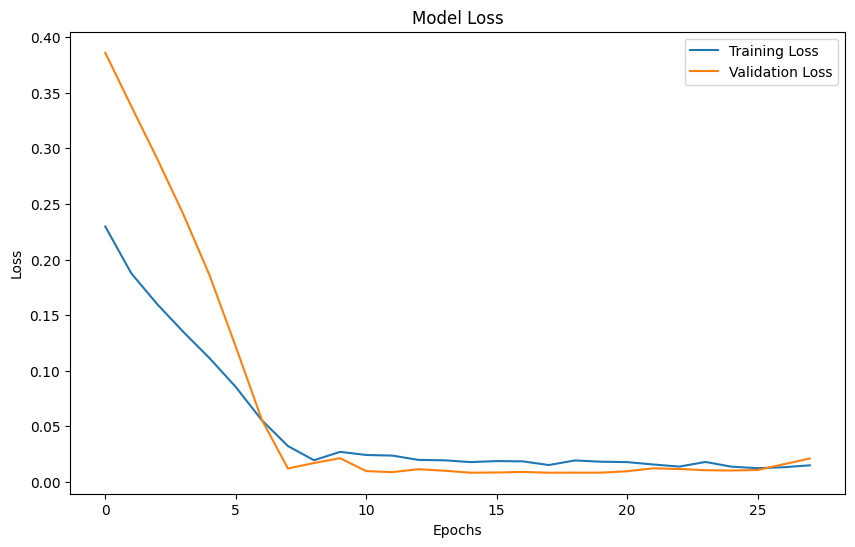

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to original scale (if normalized)
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
MAE: 138422.60
MAPE: 2.83%
RMSE: 171195.66


In [ ]:
# Create a DataFrame for test predictions
test_predictions_df = pd.DataFrame({
    'Year': df['Year'][-len(y_test_rescaled):].values,  # Extract the corresponding years
    'Month': df['Month'][-len(y_test_rescaled):].values,  # Extract the corresponding months
    'Actual': y_test_rescaled.flatten(),  # Actual values
    'Prediction': y_pred_rescaled.flatten()  # Predicted values
})

# Combine Year and Month into a Date column
test_predictions_df['Date'] = pd.to_datetime(test_predictions_df[['Year', 'Month']].assign(Day=1))

# Drop the Year and Month columns if you only need the Date
test_predictions_df = test_predictions_df[['Date', 'Actual', 'Prediction']]

# Save the predictions DataFrame to a CSV file
output_file = '/content/drive/MyDrive/THESIS/Codes/[Base] CNN-LSTM/Residential_test_predictions.csv'
test_predictions_df.to_csv(output_file, index=False)

print(f"Test predictions saved to {output_file}")

Test predictions saved to /content/drive/MyDrive/THESIS/Codes/[Base] CNN-LSTM/Residential_test_predictions.csv
